In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.impute import SimpleImputer

In [26]:
data = pd.read_csv(r"F:\download\File\ML\titanic\train.csv")

In [27]:
print(data.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [28]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


#### Cabin column is so missed up

In [29]:
null_data = data.isna().sum()
print(null_data[null_data > 0])

Age         177
Cabin       687
Embarked      2
dtype: int64


In [30]:
data = data.drop('Cabin', axis=1)

In [31]:
data['Age'] = SimpleImputer(strategy='mean').fit_transform(data[['Age']])

In [32]:
data['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [33]:
data['Embarked'] = data["Embarked"].fillna('S')

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [35]:
columns_name = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']
print("values in each column:")
for i in columns_name:
    value_counts = data[i].value_counts().to_string()
    
    print(f"{value_counts}\n")

values in each column:
Survived
0    549
1    342

Pclass
3    491
1    216
2    184

Sex
male      577
female    314

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1

Embarked
S    646
C    168
Q     77



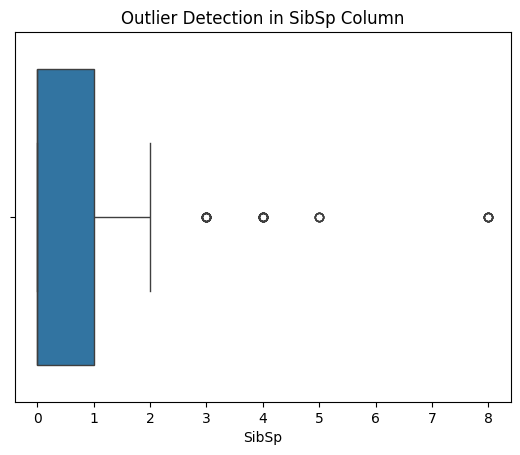

In [36]:
sns.boxplot(data=data, x='SibSp')
plt.title('Outlier Detection in SibSp Column')
plt.show()

In [37]:
data[data['SibSp'] == 5]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
59,60,0,3,"Goodwin, Master. William Frederick",male,11.0,5,2,CA 2144,46.9,S
71,72,0,3,"Goodwin, Miss. Lillian Amy",female,16.0,5,2,CA 2144,46.9,S
386,387,0,3,"Goodwin, Master. Sidney Leonard",male,1.0,5,2,CA 2144,46.9,S
480,481,0,3,"Goodwin, Master. Harold Victor",male,9.0,5,2,CA 2144,46.9,S
683,684,0,3,"Goodwin, Mr. Charles Edward",male,14.0,5,2,CA 2144,46.9,S


In [38]:
data[data['SibSp'] == 8]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,29.699118,8,2,CA. 2343,69.55,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,29.699118,8,2,CA. 2343,69.55,S
201,202,0,3,"Sage, Mr. Frederick",male,29.699118,8,2,CA. 2343,69.55,S
324,325,0,3,"Sage, Mr. George John Jr",male,29.699118,8,2,CA. 2343,69.55,S
792,793,0,3,"Sage, Miss. Stella Anna",female,29.699118,8,2,CA. 2343,69.55,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,29.699118,8,2,CA. 2343,69.55,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,29.699118,8,2,CA. 2343,69.55,S


### - Cleaning outliers and missing data

In [39]:
data = data[(data['SibSp'] != 8) & (data['SibSp'] != 5)]

In [40]:
data = data[(data['Parch'] != 5) & (data['Parch'] != 3) & (data['Parch'] != 4) & (data['Parch'] != 6)]

In [41]:
data = data.drop('Ticket', axis=1)

In [42]:
data = data.drop('Name', axis=1)

In [43]:
data['Gender'] = data['Sex']
data = data.drop('Sex', axis=1)

In [44]:
data = data.drop('PassengerId', axis=1)
data.index = data.index + 1

In [45]:
data.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,Gender
1,0,3,22.0,1,0,7.2500,S,male
2,1,1,38.0,1,0,71.2833,C,female
3,1,3,26.0,0,0,7.9250,S,female
4,1,1,35.0,1,0,53.1000,S,female
5,0,3,35.0,0,0,8.0500,S,male


In [46]:
data.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'Gender'],
      dtype='object')

### - Fare classification based on official Fare ranges into four categories: *Low*, *Medium*, *High*, and *Very High*.

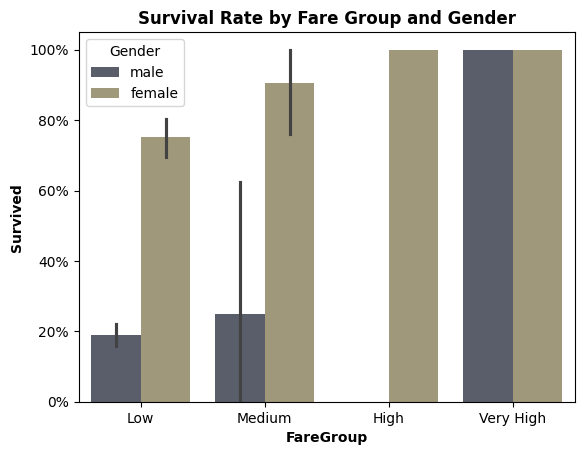

In [47]:
data['FareGroup'] = pd.cut(data['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])

bar_plot = sns.barplot(data=data, x=data['FareGroup'], y=data['Survived'], hue=data['Gender'], palette='cividis')

plt.title('Survival Rate by Fare Group and Gender', fontweight='bold')
plt.xlabel('FareGroup', fontweight='bold')
plt.ylabel('Survived', fontweight='bold')
bar_plot.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

### - An Analysis of Gender and Its Impact on Survival

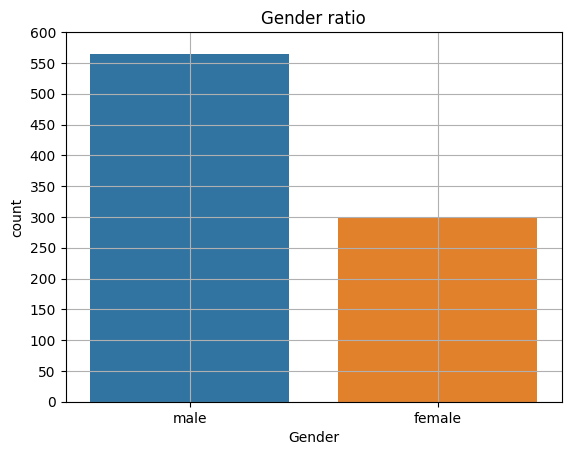

In [48]:
sns.countplot(data=data, x=data['Gender'], hue=data['Gender'])

plt.title('Gender ratio')
plt.yticks(range(0, 601, 50))
plt.grid()

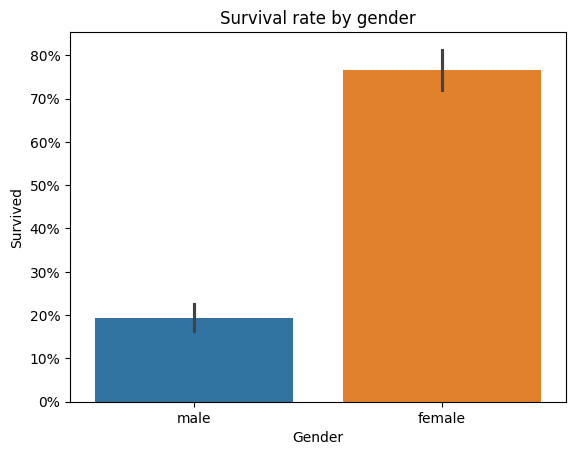

In [49]:
bar_plot = sns.barplot(data=data, x=data['Gender'], y=data['Survived'], hue=data['Gender'])

plt.title('Survival rate by gender')
bar_plot.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

### - Analysis of survival rates based on passenger class
* 1 ---> First Class
* 2 ---> Second Class
* 3 ---> Third Class

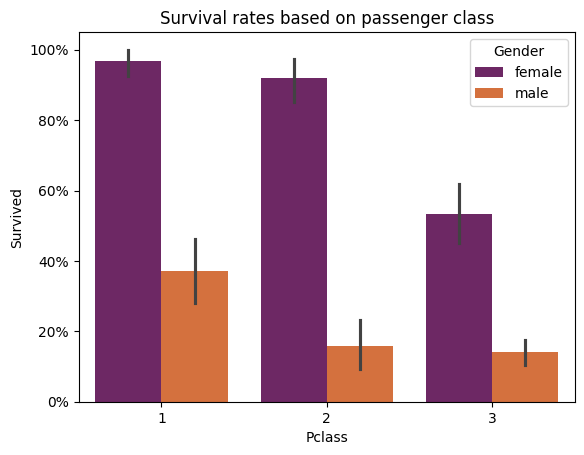

In [50]:
bar_plot = sns.barplot(data=data, x=data['Pclass'], y=data['Survived'], hue=data['Gender'], palette='inferno')

plt.title('Survival rates based on passenger class')
bar_plot.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

### - Analysis of relationships and passenger numbers

In [51]:
data['Parch'].value_counts()

Parch
0    678
1    118
2     68
Name: count, dtype: int64

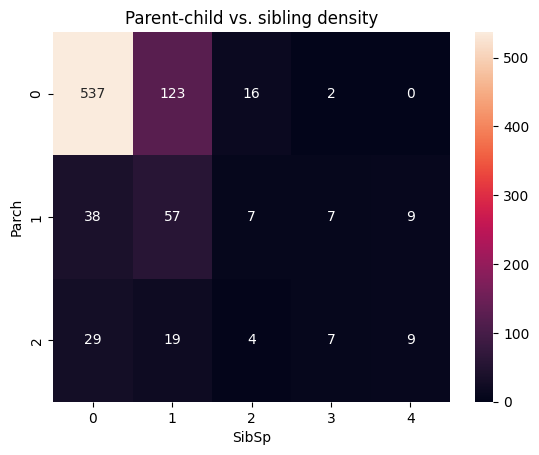

In [52]:
ct = pd.crosstab(data['Parch'], data['SibSp'])

sns.heatmap(ct, annot=True, fmt='d')

plt.title('Parent-child vs. sibling density')
plt.show()

### - Examining the impact of the mounted pier on survival rates.
##### - (each pier has its own specific price and serves as an indicator of wealth)
* C = Cherbourg
* Q = Queenstown
* S = Southampton

Text(0, 0.5, 'Survived')

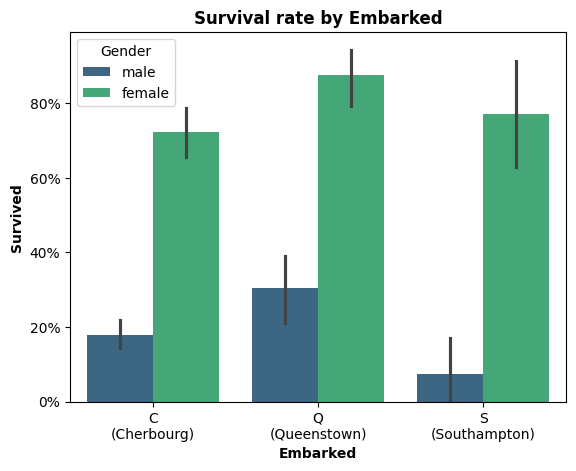

In [53]:
bar_plot = sns.barplot(data=data, x=data['Embarked'], y=data['Survived'], hue=data['Gender'], palette='viridis')

plt.title('Survival rate by Embarked', fontweight='bold')

ticks = bar_plot.get_xticks()
bar_plot.set_xticks(ticks)
bar_plot.set_xticklabels(['C\n(Cherbourg)', 'Q\n(Queenstown)', 'S\n(Southampton)'])
bar_plot.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xlabel('Embarked', fontweight='bold')
plt.ylabel('Survived', fontweight='bold')

### - Age classification based on official age ranges into five categories: *Child*, *Teen*, *Young Adult*, *Adult*, and *Senior*.

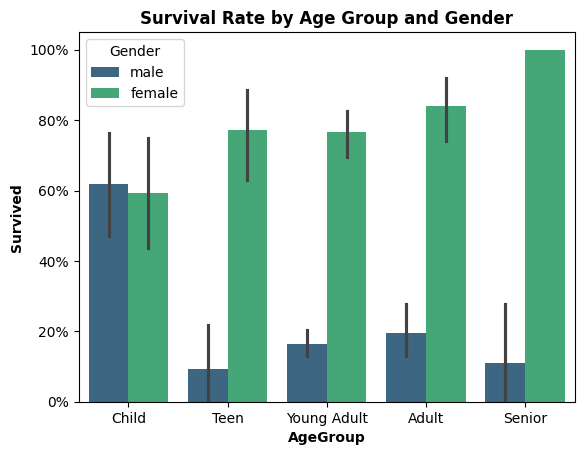

In [54]:

data['AgeGroup'] = pd.cut(data['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

bar_plot = sns.barplot(data=data, x=data['AgeGroup'], y=data['Survived'], hue=data['Gender'], palette='viridis')

plt.title('Survival Rate by Age Group and Gender', fontweight='bold')
plt.xlabel('AgeGroup', fontweight='bold')
plt.ylabel('Survived', fontweight='bold')
bar_plot.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

### - Categorizing families based on *SibSp* and *Parch*

In [55]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

In [56]:
data.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'Gender', 'FareGroup', 'AgeGroup', 'FamilySize'],
      dtype='object')

In [57]:
data['FamilySize'].value_counts()

FamilySize
1    537
2    161
3    102
4     28
6     16
5     11
7      9
Name: count, dtype: int64

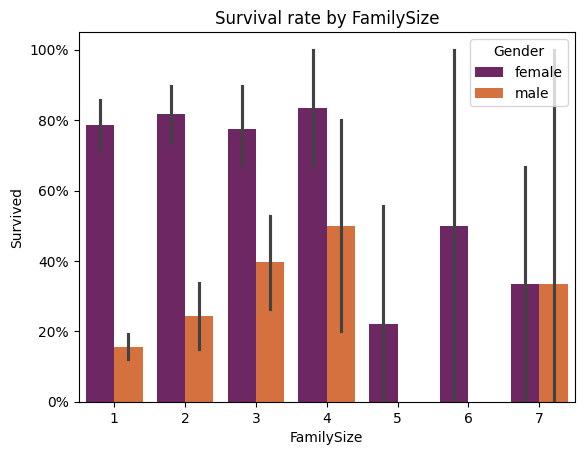

In [58]:
bar_plot = sns.barplot(data=data, x=data['FamilySize'], y=data['Survived'], hue=data['Gender'], palette='inferno')

plt.title('Survival rate by FamilySize')
bar_plot.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

In [59]:
data['FarePerPerson'] = data['Fare'] / data['FamilySize']

In [60]:
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

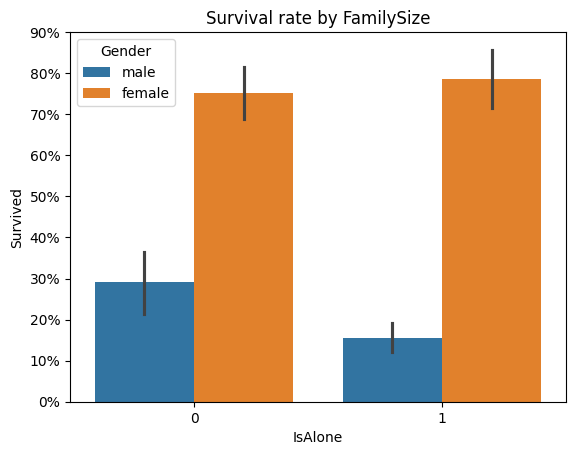

In [62]:
bar_plot = sns.barplot(data=data, x=data['IsAlone'], y=data['Survived'], hue=data['Gender'])

plt.title('Survival rate by FamilySize')
bar_plot.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))